# Bài tập thực hành tuần 2
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

### Bài tập 1:
**Câu hỏi**:

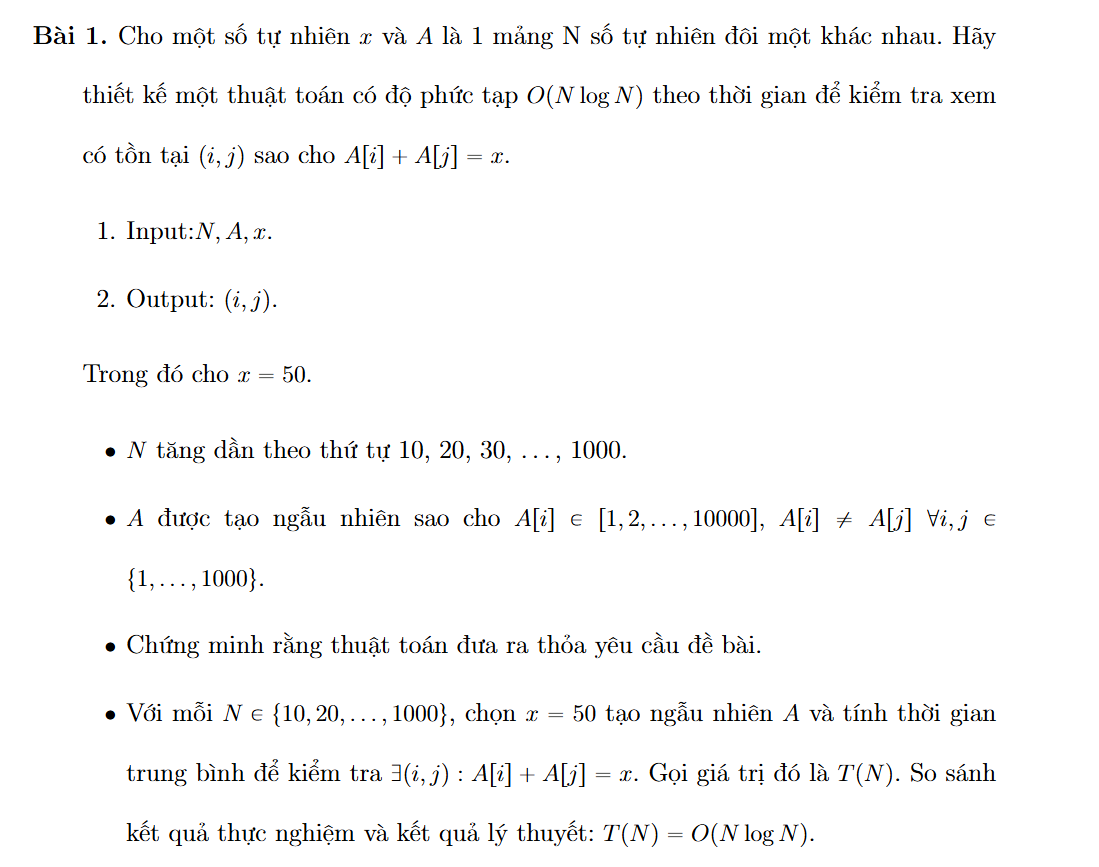

### Bài tập 1.2:
**Câu hỏi**: 

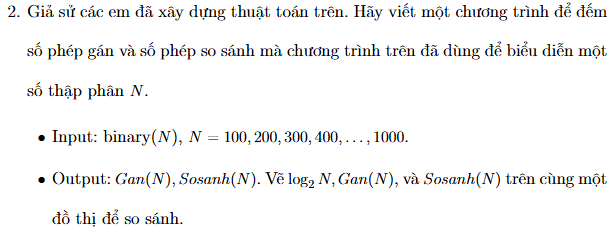


```python
def binary(n):
    if n < 0:
        raise ValueError("Error: n is negative")
    # skip n < 0 because input is N = 100, 200, ..., 1000 

    gan = 0
    soSanh = 0
    bin = ''
    while n:
        soSanh += 1
        div = str(n % 2)
        bin += div
        n //= 2
        
        gan += 3 # 1 for div, 1 for bin, 1 for n

    soSanh += 1 # Because the last comparison break the while loop
    return bin[::-1], gan, soSanh


N = [100*i for i in range(1, 11)]
assignments, comparisons = [], []
for n in N:
    bin, gan, soSanh = binary(n)
    assignments.append(gan)
    comparisons.append(soSanh)
    print(f'binary({n}) = {bin} with assignments = {gan}, comparisons = {soSanh}')

# Plot for Gan(N) and SoSanh(N) and Log2N
from math import log2
import matplotlib.pyplot as plt

log2_plot = list(map(lambda x: log2(x), N))
plt.plot(log2_plot, label='Log2N')
plt.plot(assignments, label='Gan(N)')
plt.plot(comparisons, label='Sosanh(N)')
plt.xlabel('N')
plt.xticks([i for i in range(10)], N)
plt.legend()
plt.show()
```

Giống như 'binary' phân tích ở trên thì ở đây ta chỉnh lại thì ta thêm các biến đếm

```python
gan = 0
soSanh = 0
```
Trong vòng lặp `while`, ta tăng biến `soSanh` mỗi lần so sánh điều kiện `n` và tăng biến `gan` cho mỗi phép gán (gồm phép gán `div`, phép gán `bin`, và phép gán `n`).
```python
while n:
    soSanh += 1
    div = str(n % 2)
    bin += div
    n //= 2
    
    gan += 3 # 1 for div, 1 for bin, 1 for n
```
Sau khi vòng lặp kết thúc, ta cũng tăng `soSanh` thêm 1 để đếm lần so sánh cuối cùng đã làm cho điều kiện `n` trở thành False.

```python
soSanh += 1 # Because the last comparison break the while loop
```

Cuối cùng, ta trả về chuỗi nhị phân cùng với số lượng phép gán và so sánh đã thực hiện.

```python
return bin[::-1], gan, soSanh
```

Sau đó, ta chạy hàm `binary` cho các giá trị `N` từ 100 đến 1000 và lưu trữ số lượng phép gán và so sánh vào các danh sách `assignments` và `comparisons`. Cuối cùng, ta vẽ đồ thị để so sánh giữa `Gan(N)`, `SoSanh(N)`, và `Log2N`.


```python
N = [100*i for i in range(1, 11)]
assignments, comparisons = [], [] 
for n in N:
    bin, gan, soSanh = binary(n)
    assignments.append(gan)
    comparisons.append(soSanh)
    print(f'binary({n}) = {bin} with assignments = {gan}, comparisons = {soSanh}')
# Plot for Gan(N) and SoSanh(N) and Log2N
from math import log2
import matplotlib.pyplot as plt

log2_plot = list(map(lambda x: log2(x), N))
plt.plot(log2_plot, label='Log2N')
plt.plot(assignments, label='Gan(N)')
plt.plot(comparisons, label='Sosanh(N)')
plt.xlabel('N')
plt.xticks([i for i in range(10)], N)
plt.legend()
plt.show()
```

Note: tạo mảng assignments và comparisons để lưu trữ số lượng phép gán và so sánh tương ứng với mỗi giá trị của N, sau đó sử dụng chúng để vẽ đồ thị.


### Bài tập 2:
**Câu hỏi**: 
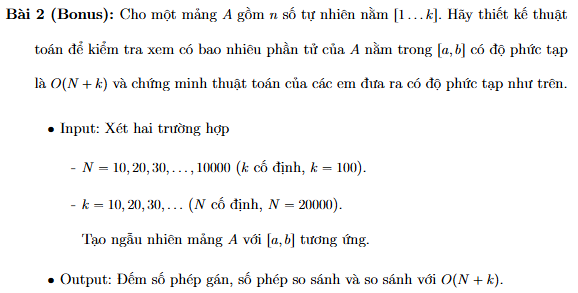

```python
from random import randint

def create_ab(k):
    a = randint(1, k)
    b = randint(1, k)
    while a >= b:
        a = randint(1, k)
        b = randint(1, k)
    return a, b

def createRandomArray(N, k):
    return [randint(1, k) for _ in range(N)]

def algorithm(A, a, b, k):
    count = [0] * (k + 1)
    cum_sum = [0] * (k + 1)
    assignment = 1
    comparison = 0

    for num in A:
        count[num] += 1
        assignment += 1

    
    cum_sum[0] = count[0]
    assignment += 2

    for i in range(1, k + 1):
        cum_sum[i] = cum_sum[i - 1] + count[i]
        assignment += 1

    result = cum_sum[b] - cum_sum[a - 1]
    return result, assignment, comparison

# TH1
bigO_list = []
assignments = []
comparisons = []
k = 100
for N in [10*i for i in range(1, 1001)]:
    A = createRandomArray(N, k)
    a, b = create_ab(k)
    result, assignment, comparison = algorithm(A, a, b, k)
    bigO = N + k

    bigO_list.append(bigO)
    assignments.append(assignment)
    comparisons.append(comparison)

plt.figure(figsize=(10, 5))
plt.plot(bigO_list, label='O(N+k)')
plt.plot(assignments, label='Gan(N, k)')
plt.plot(comparisons, label='Sosanh(N, k)')
plt.xlabel('N')
plt.legend()
plt.title('TH 1: k = 100')
plt.show()

# TH2
bigO_list = []
assignments = []
comparisons = []
N = 20000
for k in [10*i for i in range(1, 1001)]:
    A = createRandomArray(N, k)
    a, b = create_ab(k)
    result, assignment, comparison = algorithm(A, a, b, k)
    bigO = N + k
    bigO_list.append(bigO)
    assignments.append(assignment)
    comparisons.append(comparison)

plt.figure(figsize=(10, 5))
plt.plot(bigO_list, label='O(N+k)')
plt.plot(assignments, label='Gan(N, k)')
plt.plot(comparisons, label='Sosanh(N, k)')
plt.xlabel('k')
plt.legend()
plt.title('TH 2: N = 20000')
plt.show()
```

Để thuật toán đạt O(N + k), ta cần đảm bảo rằng số lượng phép gán và so sánh của thuật toán không vượt quá một hằng số nhân với N + k. Trong thuật toán đã cho, ta có:
- Vòng lặp đầu tiên chạy qua tất cả phần tử của mảng A, thực hiện N phép gán (để update '
`count`) và N phép so sánh (để kiểm tra điều kiện của vòng lặp).
```python
for num in A:
    count[num] += 1
    assignment += 1
```
- Vòng lặp thứ hai chạy qua tất cả phần tử của mảng cum_sum, thực hiện k phép gán (để cập nhật mảng cum_sum) và k phép so sánh (để kiểm tra điều kiện của vòng lặp).
```python
for i in range(1, k + 1):
    cum_sum[i] = cum_sum[i - 1] + count[i]
    assignment += 1
```

- Để chứng minh rõ hơn thì chúng ta có đồ thị số lượng phép gán và so sánh theo N và k, ta sẽ thấy rằng số lượng phép gán và so sánh đều tăng tuyến tính với N và k, do đó thuật toán đạt O(N + k) có thể thấy ở dưới đây:
```python
for N in [10*i for i in range(1, 1001)]:
    A = createRandomArray(N, k)
    a, b = create_ab(k)
    result, assignment, comparison = algorithm(A, a, b, k)
    bigO = N + k

    bigO_list.append(bigO)
    assignments.append(assignment)
    comparisons.append(comparison)
plt.figure(figsize=(10, 5))
plt.plot(bigO_list, label='O(N+k)')
plt.plot(assignments, label='Gan(N, k)')
plt.plot(comparisons, label='Sosanh(N, k)')
plt.xlabel('N')
plt.legend()
plt.show()
```
Note các hàm ngoài:
- `create_ab(k)`: Hàm này tạo ra hai số nguyên ngẫu nhiên `a` và `b` trong khoảng từ 1 đến k, đảm bảo rằng `a < b`.
```python
def create_ab(k):
    a = randint(1, k)
    b = randint(1, k)
    while a >= b:
        a = randint(1, k)
        b = randint(1, k)
    return a, b
```
- `createRandomArray(N, k)`: Hàm này tạo ra một mảng ngẫu nhiên gồm N phần tử, mỗi phần tử có giá trị trong khoảng từ 1 đến k.
```python
def createRandomArray(N, k):
    return [randint(1, k) for _ in range(N)]
```